# House Prices - Advanced Regression Techniques

## Features

Versión anterior - Boston Housing Dataset

Metadatos:


Metas:
Predecir los precios de las ventas para cada casa (para cada ID en el *test set*)
Tienes que predecir el valor de la variable *SalesPrice*

Métricas:
Se evaluan a partir del RMSE (Root Mean Squared Error) entre el logaritmo del valor predicto y el logaritmo de los precios de ventas observados.

In [69]:
import pandas as pd

In [70]:
# Importación de datos

df_entrenamiento = pd.read_csv("train.csv")
df_pruebas = pd.read_csv("test.csv")
df_muestra = pd.read_csv("sample_submission.csv")

El problema ya nos determinó los datos de entrenamiento y de prueba. En este momento vamos a trabajar con el dataset completo, realizando una exploración de sus atributos y relaciones

In [71]:
print("Entrenamiento")
print(len(df_entrenamiento))
print("pruebas")
print(len(df_pruebas))

Entrenamiento
1460
pruebas
1459


In [72]:
# df_sector_inmobiliario = pd.concat([df_entrenamiento,df_pruebas], axis = 0)

# df_sector_inmobiliario

Utilizamos el dataset de entrenamiento ya que con esta información será la calidad del modelo

In [73]:
df_entrenamiento.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [74]:
# Forma y tipo de datos.
df_entrenamiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

La pregunta objetivo es:

- ¿Cuanto valdrán las casas en un futuro? | Determinar los precios de venta futuros

Siempre es bueno utilizar gráficas para dar una descripción de los datos. 

-¿Pero, que gráficas nos serán óptimas y que variables son importantes para su representación gráfica?

- ¿Los datos tendrán la calidad necesaria? (sobre los outliers, valores nulos, etc)

Primeramente utilizaremos una gráfica de distribución (histograma) para la variable principal *SalePrice*

In [75]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 900x800 with 0 Axes>

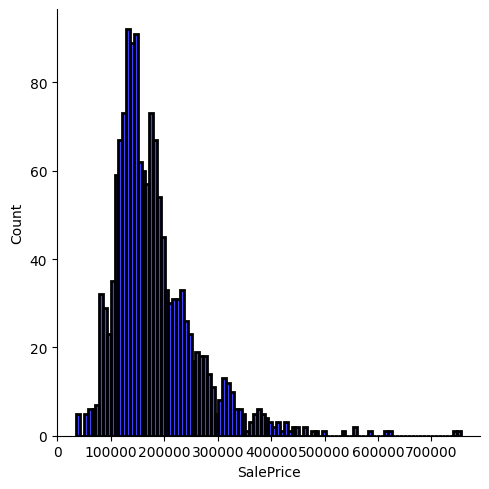

In [76]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(9,8))
sns.displot(df_entrenamiento['SalePrice'], color = 'b', bins = 100, edgecolor="k", linewidth=2)



In [77]:
list(set(df_entrenamiento.dtypes.tolist()))



[dtype('float64'), dtype('int64'), dtype('O')]

Ya que los modelos de predicción toman tipos de valores particulares, vamos a separar los cuantitativos de los cualitativos

Los tipos de datos numericos son
- *int64* -> Discretos
- *float64* -> Flotantes

In [78]:
df_cuantitativo = df_entrenamiento.select_dtypes(include=['int64','float64'])

df_cuantitativo.columns


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

ANSWER: debido a que lo que queremos predecir son las precios de ventas, y esta variable es cuantitativa discreta, implica que es un *PROBLEMA DE REGRESIÓN*

Entonces tenemos que enfocarnos en modelos de *Aprendizaje Supervisado*

De los modelos que podemos aplicar serán:
- Regresión lineal
- Regresión polinómica
- Máquina de soporte vectorial
- Arboles de decisión y ensambles

Y sus métodos de evaluación serán:
- MSE (Error Cuadrático Medio)
- MAE (Error Absoluto Medio)
- R2 (Coeficiente de determinación)

Para esto, tenemos que determinar si vamos a realizar un preprocesamiento antes de aplicar cualquier modelo.

- Normalización y estandarización: Escalar las características de los datos para que tengan valores comparables, lo que mejora el rendimiento de ciertos algoritmos como la regresión lineal y SVR.

- Imputación de valores faltantes: Los datos incompletos pueden distorsionar los resultados del modelo, por lo que es crucial manejar los valores faltantes de manera adecuada.

- Transformaciones de características: Aplicar transformaciones como logaritmos o raíces cuadradas a las variables puede ayudar a normalizar la distribución y mejorar la capacidad del modelo para ajustarse a los datos.

La pregunta es, ¿Como sabemos si vamos a requerir algun preprocesamiento?
Al aplicar los métodos no necesitamos de tener la columna *id*

## Regresión lineal simple

Para que la regresión lineal produzca resultados fiables, deben cumplirse ciertos supuestos:

- Linealidad: La relación entre la variable independiente y la dependiente debe ser lineal.
- Independencia de los errores: Los residuos (errores) no deben estar correlacionados entre sí.
- Varianza constante (homocedasticidad): La dispersión de los residuos debe permanecer constante en todos los valores.
- Normalidad de los residuos: Los residuos deben seguir una distribución normal.

vamos a graficar (gráficos de dispersión) las variables cuantitativas con respecto a la variable *SalePrice*



In [79]:
print(df_cuantitativo.columns)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')


In [80]:
atributo = 'GrLivArea'

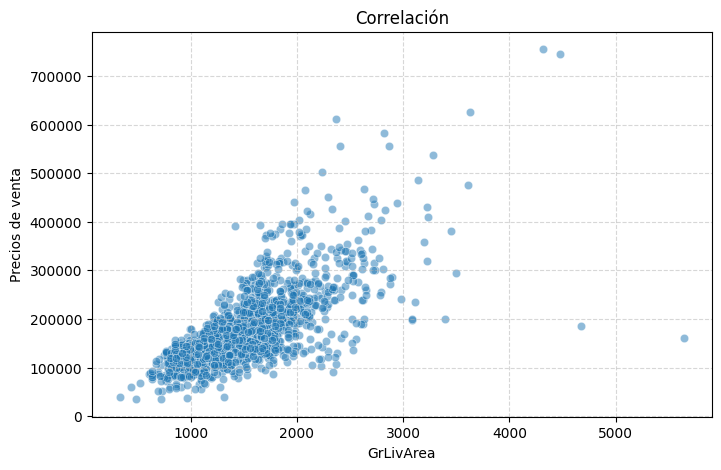

In [81]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = df_cuantitativo, x=atributo , y='SalePrice', alpha = 0.5)
plt.title("Correlación")
plt.xlabel(atributo)
plt.ylabel('Precios de venta')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

Podemos ver por la gráfica varios outliers, podriamos discriminar los valores en un rango de 
- x : [0,400]
- y = [0,700]

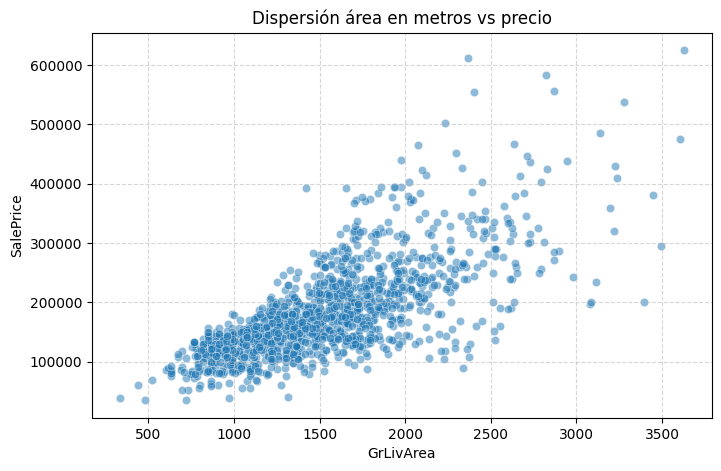

In [82]:
df_cuantitativo_filtrado = df_cuantitativo[df_cuantitativo['GrLivArea'] < 4000]

plt.figure(figsize=(8,5))
sns.scatterplot(data = df_cuantitativo_filtrado, x = atributo, y='SalePrice', alpha = 0.5)
plt.title("Dispersión área en metros vs precio")
plt.xlabel(atributo)
plt.ylabel('SalePrice')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

Esto nos dice la intuición a partir de lo que conocemos de los datos, pero que hay de las demas variables? grafiquemoslas.


In [83]:
df_cuantitativo.reset_index(inplace = True)

df_cuantitativo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 39 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1460 non-null   int64  
 1   Id             1460 non-null   int64  
 2   MSSubClass     1460 non-null   int64  
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   OverallQual    1460 non-null   int64  
 6   OverallCond    1460 non-null   int64  
 7   YearBuilt      1460 non-null   int64  
 8   YearRemodAdd   1460 non-null   int64  
 9   MasVnrArea     1452 non-null   float64
 10  BsmtFinSF1     1460 non-null   int64  
 11  BsmtFinSF2     1460 non-null   int64  
 12  BsmtUnfSF      1460 non-null   int64  
 13  TotalBsmtSF    1460 non-null   int64  
 14  1stFlrSF       1460 non-null   int64  
 15  2ndFlrSF       1460 non-null   int64  
 16  LowQualFinSF   1460 non-null   int64  
 17  GrLivArea      1460 non-null   int64  
 18  BsmtFull

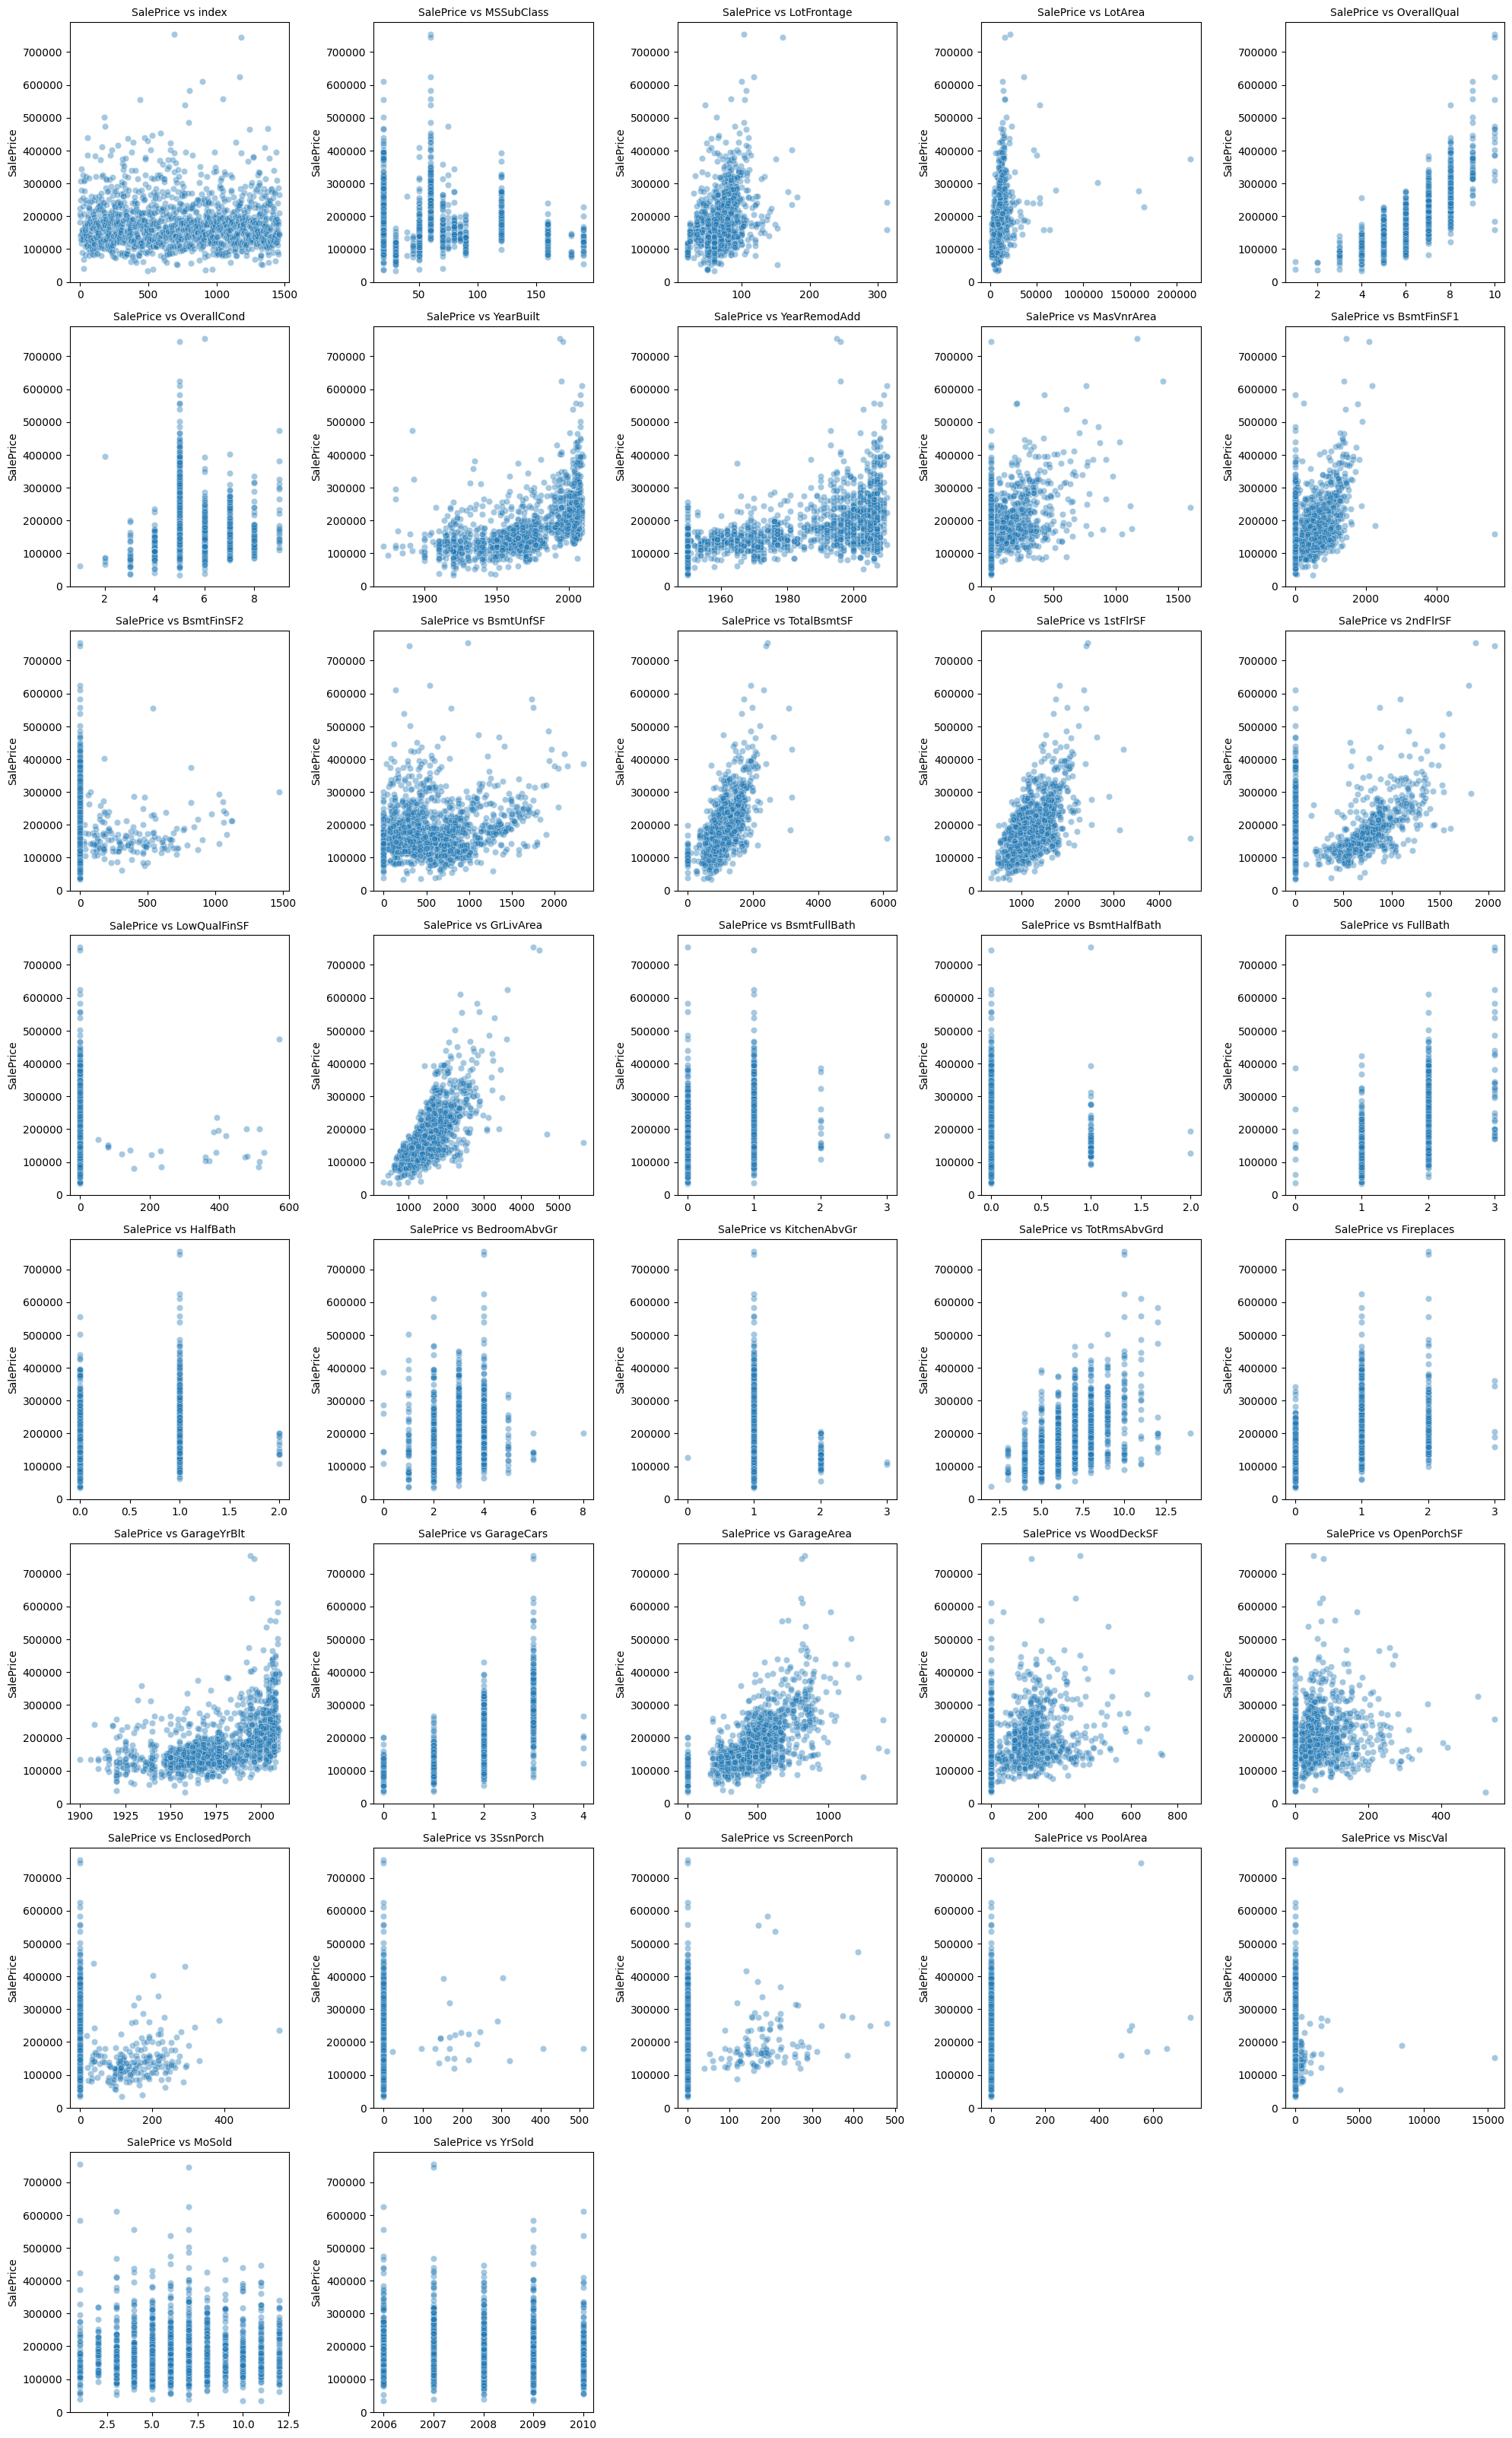

In [84]:
import math

df_cuantitativo.drop(columns = ['Id'], inplace = True)
atributos = df_cuantitativo.drop("SalePrice", axis = 1)


#Determinamos cuantas columnas tendremos en nuestra malla
n_cols = 5
n_rows = math.ceil(len(atributos)/n_cols)

#Creamos el lienzo
fig, axes = plt.subplots(n_rows,n_cols,figsize= (20, n_rows*4))
axes = axes.flatten()       # Convertimos la matriz de ejes en una lista simple para iterar

for j, col in enumerate(atributos):
    sns.scatterplot(data = df_cuantitativo, x = col , y = 'SalePrice' ,ax = axes[j] , alpha = 0.4)
    
    #Estetica para evitar amontonamiento
    axes[j].set_title(f"SalePrice vs {col}",fontsize = 10)
    axes[j].set_xlabel('')
    axes[j].set_xlabel('')

#Eliminamos cuadros que sobren

for j in range(j + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Podemos hacer una segunda validación de *cuales atributos son los mejores para realizar una regresión lineal (el más óptimo, y los más óptimos).

Para esto usamos la *correlación de pearson*

In [85]:
correlaciones = df_cuantitativo.corr()['SalePrice']

correlaciones.sort_values(ascending= False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
index           -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

Trabajaremos con *OverallQuall* para la regresión lineal simple y -*GirLivArea, GarageCars, GarageArea, TotalBsmtSF* para la regresión lineal multiple

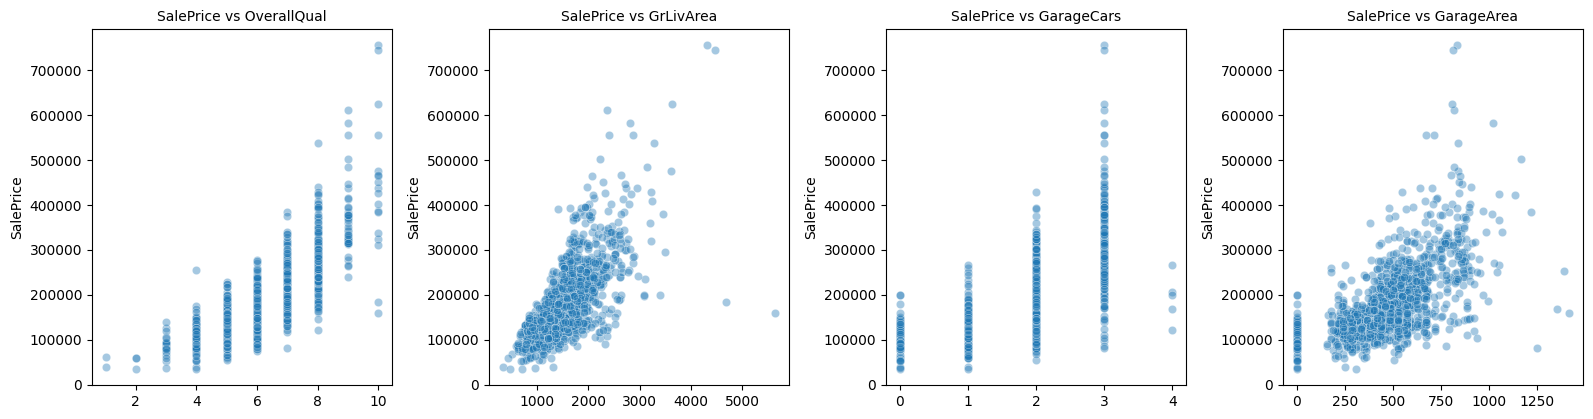

In [86]:
atributos_seleccionados = ['OverallQual','GrLivArea','GarageCars','GarageArea']
n_col = 2
n_rows = math.ceil(len(atributos_seleccionados)/n_col)

fig, axes = plt.subplots(n_rows,n_cols,figsize= (20, n_rows*4))
axes = axes.flatten()       # Convertimos la matriz de ejes en una lista simple para iterar

for j, col in enumerate(atributos_seleccionados):
    sns.scatterplot(data = df_cuantitativo, x = col , y = 'SalePrice' ,ax = axes[j] , alpha = 0.4)
    
    #Estetica para evitar amontonamiento
    axes[j].set_title(f"SalePrice vs {col}",fontsize = 10)
    axes[j].set_xlabel('')
    axes[j].set_xlabel('')

for j in range(j + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Determinamos si existen (para regresión lineal simple):
- Outliers (el más importante)
- Valores nulos (¿cuantos?)
- Duplicados
- Datos mentira

In [111]:
print("VALORES NULOS")
print(df_cuantitativo[['OverallQual','GrLivArea','GarageCars','GarageArea','SalePrice']].isnull().sum())

print("OUTLIERS:")
print(df_cuantitativo[['OverallQual','GrLivArea','GarageCars','GarageArea','SalePrice']].describe())


print("DUPLICADOS EXACTOS")
print(df_cuantitativo.duplicated().sum())

print("FILAS A ANALIZAR")
print(df_cuantitativo[df_cuantitativo.duplicated(keep = False)])

VALORES NULOS
OverallQual    0
GrLivArea      0
GarageCars     0
GarageArea     0
SalePrice      0
dtype: int64
OUTLIERS:
       OverallQual    GrLivArea   GarageCars   GarageArea      SalePrice
count  1460.000000  1460.000000  1460.000000  1460.000000    1460.000000
mean      6.099315  1515.463699     1.767123   472.980137  180921.195890
std       1.382997   525.480383     0.747315   213.804841   79442.502883
min       1.000000   334.000000     0.000000     0.000000   34900.000000
25%       5.000000  1129.500000     1.000000   334.500000  129975.000000
50%       6.000000  1464.000000     2.000000   480.000000  163000.000000
75%       7.000000  1776.750000     2.000000   576.000000  214000.000000
max      10.000000  5642.000000     4.000000  1418.000000  755000.000000
DUPLICADOS EXACTOS
0
FILAS A ANALIZAR
Empty DataFrame
Columns: [index, MSSubClass, LotFrontage, LotArea, OverallQual, OverallCond, YearBuilt, YearRemodAdd, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFl

VALORES DUPLICADOS EN LA VARIABLE OBJETIVO Y MAPA D CALOR
SalePrice
140000    20
135000    17
155000    14
145000    14
190000    13
          ..
202665     1
164900     1
208300     1
181500     1
147500     1
Name: count, Length: 663, dtype: int64


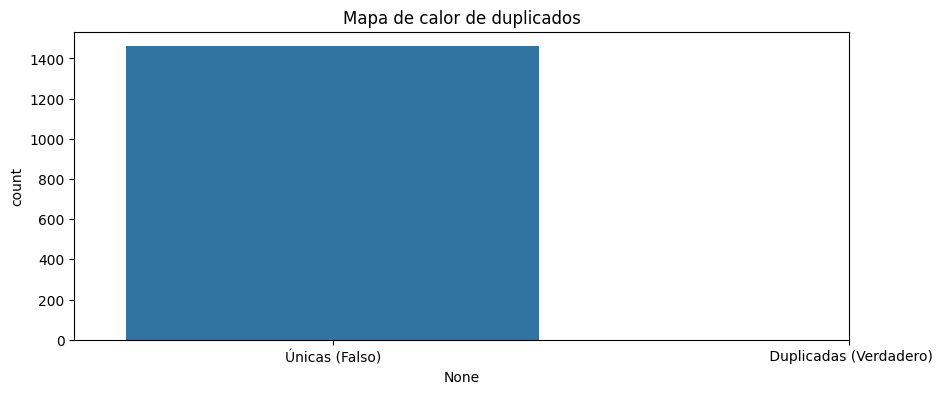

In [114]:
print("VALORES DUPLICADOS EN LA VARIABLE OBJETIVO Y MAPA D CALOR")
print(df_cuantitativo['SalePrice'].value_counts())

plt.figure(figsize=(10,4))
sns.countplot(x=df_cuantitativo.duplicated())
plt.title("Mapa de calor de duplicados")
plt.xticks([0,1], ['Únicas (Falso)', ' Duplicadas (Verdadero)'])
plt.show()


### Regresión lineal simple.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# Elegimos OverallQuall

x_simple = df_cuantitativo[['OverallQual']]
y = df_cuantitativo[['SalePrice']]

#Tomamos los datos de entrenamiento que nos propone Kaggle

modelo_simple = LinearRegression()
modelo_simple.fit(x_simple,y)


print(f"R2 Simple: {modelo_simple.score(x_simple, y):.4f}")
print(f"La fórmula del modelo simple es: Precio = {modelo_simple.intercept_} + {modelo_simple.coef_[0]} * OverallQuall")

R2 Simple: 0.6257
La fórmula del modelo simple es: Precio = [-96206.07951476] + [45435.8025931] * Calidad


### Regresión lineal multiple.

In [ ]:
atributos_seleccionados


['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea']

In [119]:
x_multiple = df_cuantitativo[atributos_seleccionados]

modelo_multiple = LinearRegression()
modelo_multiple.fit(x_multiple,y)     #la y definida en la regresión lineal simple


print(f"R2 Simple: {modelo_multiple.score(x_multiple, y):.4f}")
print(f"La fórmula del modelo simple es: ordenada al origen = {modelo_multiple.intercept_} con coeficientes:{modelo_multiple.coef_[0]}")

R2 Simple: 0.7418
La fórmula del modelo simple es: ordenada al origen = [-98436.04983173] con coeficientes:[26988.85400401    49.57281194 11317.5224234     41.47841719]


A partir del modelo, calculamos las predicciones para el conjunto de prueba

In [ ]:
#Predicción

y_pred_regresion_simple = modelo_simple.predict(df_pruebas['OverallQuall'])
y_pred_regresion_multiple =  modelo_multiple.predict(df_pruebas[['OverallQual','GrLivArea','GarageCars','GarageArea']])

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

# #Calculo del MAE,RMSE,R2
# mae_simple = mean_absolute_error(df_pruebas['SalePrice'], y_pred_regresion_simple)
# rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_simple))

# # 3. Calculamos métricas para el Modelo Múltiple
# mae_m = mean_absolute_error(y_test, y_pred_mult)
# rmse_m = np.sqrt(mean_squared_error(y_test, y_pred_mult))

# print(f"MODELO SIMPLE -> MAE: ${mae_s:,.2f} | RMSE: ${rmse_s:,.2f}")
# print(f"MODELO MÚLTIPLE -> MAE: ${mae_m:,.2f} | RMSE: ${rmse_m:,.2f}")
